# Example of treatments available

This notebook shows how to use some extra features for your gridmarthe treatments


In [1]:
# import modules
import numpy as np
import gridmarthe as gm
import matplotlib.pyplot as plt

In [2]:
grid = gm.load_marthe_grid('./data/craie_npc.permh', drop_nan=True)  # NaN needs to be drop or set (change 0 to nan for permh for example)
grid

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 1, zone: 101209)
Coordinates:
  * time     (time) datetime64[ns] 8B 1850-01-01
  * zone     (zone) int32 405kB 47402 47403 47763 ... 2381150 2381151 2381457
Data variables:
    permeab  (time, zone) float64 810kB 1e-05 1e-05 1e-05 ... 0.0001 0.0001
    x        (zone) float32 405kB 6.372e+05 6.378e+05 ... 6.382e+05 6.38e+05
    y        (zone) float32 405kB 2.617e+06 2.617e+06 ... 2.592e+06 2.592e+06
    dx       (zone) float32 405kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    dy       (zone) float32 405kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    z        (zone) int32 405kB 1 1 1 1 1 1 1 1 1 1 1 ... 9 9 9 9 9 9 9 9 9 9 9
Attributes: (12/17)
    conventions:          CF-1.10
    title:                
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 387 304 10; 307 442 10
    lon_resolution:       100.0, 500.0
    lat_resolution:       100.0, 500.0
    ...                   ...
    creation_date:        Created on 2025-03-26T13:40:44Z UTC
    institution:          BRGM, French Geological Survey, Orléans, France
    comment:              Hydrogeological model created with MARTHE code (Thi...
    resolution_units:     m
    projection:           epsg:27572
    domain:               FR-France

## Get surface mask

In [3]:
surf = gm.get_surface_layer(grid)
surf

<xarray.Dataset> Size: 841kB
Dimensions:  (zone: 21025)
Coordinates:
  * zone     (zone) int32 84kB 178171 177784 647989 ... 1389346 1660427 1660120
Data variables:
    time     (zone) datetime64[ns] 168kB 1850-01-01 1850-01-01 ... 1850-01-01
    permeab  (zone) float64 168kB 1e-06 1e-06 0.003068 ... 1e-06 2e-05 2e-05
    x        (zone) float32 84kB 6.188e+05 6.188e+05 ... 6.494e+05 6.494e+05
    y        (zone) float32 84kB 2.6e+06 2.6e+06 ... 2.606e+06 2.606e+06
    dx       (zone) float32 84kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    dy       (zone) float32 84kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    z        (zone) int32 84kB 2 2 6 6 8 8 8 8 5 2 6 6 ... 2 2 2 2 2 2 2 2 2 4 4

In [4]:
# transform to geodataframe (not necessary, just for example) 
gdf = gm.to_geodataframe(surf)
print(gdf)
print(type(gdf))

              time       permeab         x          y     dx     dy  z  \
zone                                                                     
178171  1850-01-01  1.000000e-06  618750.0  2599850.0  500.0  500.0  2   
177784  1850-01-01  1.000000e-06  618750.0  2600350.0  500.0  500.0  2   
647989  1850-01-01  3.067630e-03  618750.0  2600850.0  500.0  500.0  6   
647602  1850-01-01  2.484310e-03  618750.0  2601350.0  500.0  500.0  6   
882511  1850-01-01  1.770000e-07  618750.0  2601850.0  500.0  500.0  8   
...            ...           ...       ...        ...    ...    ... ..   
1389960 1850-01-01  1.000000e-06  649350.0  2605850.0  100.0  100.0  2   
1389653 1850-01-01  1.000000e-06  649350.0  2605950.0  100.0  100.0  2   
1389346 1850-01-01  1.000000e-06  649350.0  2606050.0  100.0  100.0  2   
1660427 1850-01-01  2.000000e-05  649350.0  2606150.0  100.0  100.0  4   
1660120 1850-01-01  2.000000e-05  649350.0  2606250.0  100.0  100.0  4   

                                     

/home/manlaya/envs/gm/lib/python3.11/site-packages/gridmarthe/operasem/gis.py:58: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if 'time' in ds.dims.keys():


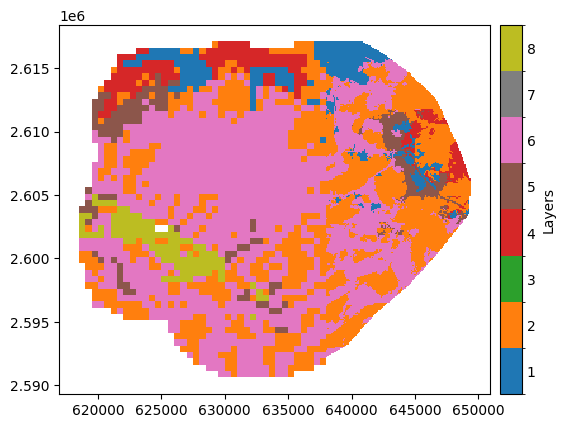

In [5]:
gm.plot_outcrop(gdf, engine='gpd')
plt.show()

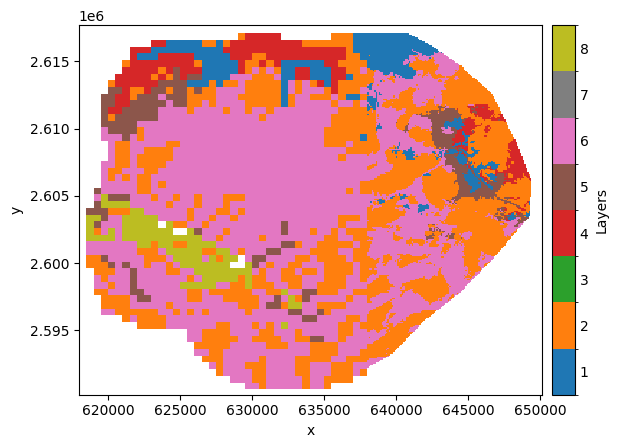

In [6]:
# xarray version
toto = gm.assign_coords(surf, add_lay=False) # add lay false because it needs to be a variable to plot, not a dimension
gm.plot_outcrop(toto)
plt.show()

## Get mask of active domain

## 

In [7]:
mask = gm.get_active_mask(grid) # return a geopandas geodataframe

/home/manlaya/envs/gm/lib/python3.11/site-packages/gridmarthe/operasem/gis.py:58: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if 'time' in ds.dims.keys():


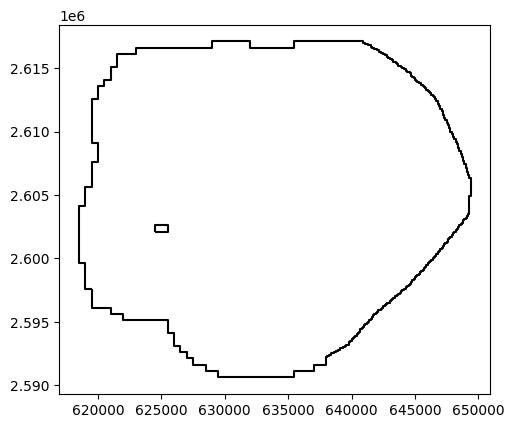

In [8]:
mask.boundary.plot(color='k')
plt.show()

## Compute depths and thickness

Users can get geometry attributes (depth, thickness, upper/lower altitudes) in a dataset:

In [9]:
topo = gm.load_marthe_grid('./data/example.topog')
hsubs = gm.load_marthe_grid('./data/example.hsubs')
geom = gm.compute_geometry(topo, hsubs)
geom


<xarray.Dataset> Size: 75MB
Dimensions:     (time: 1, zone: 1176480)
Coordinates:
  * time        (time) datetime64[ns] 8B 1850-01-01
  * zone        (zone) int32 5MB 1 2 3 4 5 ... 1176477 1176478 1176479 1176480
Data variables:
    h_topogr    (time, zone) float64 9MB 9.999e+03 9.999e+03 ... 9.999e+03
    x           (zone) float32 5MB 5.438e+05 5.442e+05 ... 7.362e+05 7.368e+05
    y           (zone) float32 5MB 2.678e+06 2.678e+06 ... 2.526e+06 2.526e+06
    dx          (zone) float32 5MB 500.0 500.0 500.0 500.0 ... 500.0 500.0 500.0
    dy          (zone) float32 5MB 500.0 500.0 500.0 500.0 ... 500.0 500.0 500.0
    z           (zone) int32 5MB 1 1 1 1 1 1 1 1 1 ... 10 10 10 10 10 10 10 10
    h_substrat  (time, zone) float64 9MB nan nan nan nan nan ... nan nan nan nan
    h_upper     (time, zone) float64 9MB nan nan nan nan nan ... nan nan nan nan
    thickness   (time, zone) float64 9MB nan nan nan nan nan ... nan nan nan nan
    depth       (time, zone) float64 9MB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/17)
    conventions:          CF-1.10
    title:                
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 387 304 10
    lon_resolution:       500.0
    lat_resolution:       500.0
    ...                   ...
    creation_date:        Created on 2025-03-26T13:41:08Z UTC
    institution:          BRGM, French Geological Survey, Orléans, France
    comment:              Hydrogeological model created with MARTHE code (Thi...
    resolution_units:     m
    projection:           epsg:27572
    domain:               FR-France

## Interpolation, regridding, transformations

### Projection transformation


In [ ]:
# Tutorial in construction